In [ ]:
import pandas as pd
from datetime import datetime

data = pd.read_excel("data.xlsx")

data = data.drop_duplicates()

columns = []

for single_data in data :
    if single_data == "":
        single_data = pd.isna()
    if data[single_data][0] == pd.StringDtype:
        columns.append(single_data)

for col in columns:
    data[col] = data[col].str.strip()

numerical_vars = ["Quantity", "UnitPrice"]

for col in numerical_vars:
    data[col] = data[col].astype(float)
    data[col] = data[col].fillna(0)
    data = data[data[col] >= 0]

data["Description"] = data[col].fillna("No description")
data = data.drop(columns=["StockCode"])
data = data.dropna(subset=["CustomerID"])


print(data.head())

  InvoiceNo  Description  Quantity         InvoiceDate  UnitPrice  CustomerID  \
0    536365         2.55       6.0 2010-12-01 08:26:00       2.55     17850.0   
1    536365         3.39       6.0 2010-12-01 08:26:00       3.39     17850.0   
2    536365         2.75       8.0 2010-12-01 08:26:00       2.75     17850.0   
3    536365         3.39       6.0 2010-12-01 08:26:00       3.39     17850.0   
4    536365         3.39       6.0 2010-12-01 08:26:00       3.39     17850.0   

          Country  
0  United Kingdom  
1  United Kingdom  
2  United Kingdom  
3  United Kingdom  
4  United Kingdom  


In [35]:
data["Montant"] = data["Quantity"] * data["UnitPrice"]
reference_date = data["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = []

for customer_id, client_df in data.groupby("CustomerID"):
    rfm.append({
        "CustomerID": customer_id,
        "Recence": (reference_date - client_df["InvoiceDate"].max()).days,
        "Frequence": client_df["InvoiceNo"].nunique(),
        "Montant": client_df["Montant"].sum()
    })

rfm = pd.DataFrame(rfm)
print(rfm)


      CustomerID  Recence  Frequence   Montant
0        12346.0      326          1  77183.60
1        12347.0        2          7   4310.00
2        12348.0       75          4   1797.24
3        12349.0       19          1   1757.55
4        12350.0      310          1    334.40
...          ...      ...        ...       ...
4334     18280.0      278          1    180.60
4335     18281.0      181          1     80.82
4336     18282.0        8          2    178.05
4337     18283.0        4         16   2045.53
4338     18287.0       43          3   1837.28

[4339 rows x 4 columns]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

X = rfm[["Recence", "Frequence", "Montant"]].copy()

X_log = np.log1p(X)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

Dimensions de X_scaled : (4339, 3)


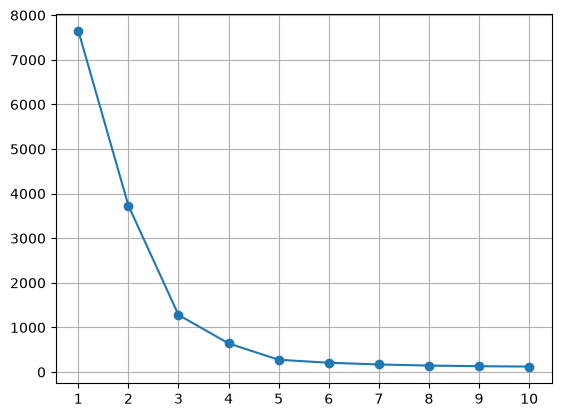

In [44]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

x , y = make_blobs(n_samples=100, centers=8, cluster_std=1, random_state=42)
inertia = []
k_range = range(1,11)

for k in k_range:
    kmeans = KMeans(
        n_clusters=k,
        n_init=10,
        random_state=42
    )

    kmeans.fit(x)
    inertia.append(kmeans.inertia_)

plt.plot(k_range, inertia, marker="o")
plt.xticks(k_range)
plt.grid()
plt.show()

In [45]:

from sklearn.preprocessing import StandardScaler
import numpy as np

kmeans_final = KMeans(
    n_clusters=3,
    init="k-means++",
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans_final.fit_predict(X_scaled)
print(rfm.head())

   CustomerID  Recence  Frequence   Montant  Cluster
0     12346.0      326          1  77183.60        2
1     12347.0        2          7   4310.00        1
2     12348.0       75          4   1797.24        2
3     12349.0       19          1   1757.55        2
4     12350.0      310          1    334.40        0


In [46]:
stats_rfm = []
cluster_dict = dict(list(rfm.groupby("Cluster")))

for cluster in cluster_dict:
    df_cluster = cluster_dict[cluster] 

    print(df_cluster)
    
    stats_rfm.append({
        "Cluster": cluster,
        "nombre_clients": df_cluster["CustomerID"].count(),
        "ca_total": df_cluster["Montant"].sum(),
        "ca_avg": df_cluster["Montant"].mean(),
        "recence_avg": df_cluster["Recence"].mean(),
        "Frequence_avg": df_cluster["Frequence"].mean()
    })

      CustomerID  Recence  Frequence  Montant  Cluster
4        12350.0      310          1   334.40        0
6        12353.0      204          1    89.00        0
7        12354.0      232          1  1079.40        0
8        12355.0      214          1   459.40        0
14       12361.0      287          1   189.90        0
...          ...      ...        ...      ...      ...
4331     18276.0       44          1   335.86        0
4332     18277.0       58          1   110.38        0
4333     18278.0       74          1   173.90        0
4334     18280.0      278          1   180.60        0
4335     18281.0      181          1    80.82        0

[1870 rows x 5 columns]
      CustomerID  Recence  Frequence  Montant  Cluster
1        12347.0        2          7  4310.00        1
5        12352.0       36          8  2506.04        1
15       12362.0        3         10  5226.23        1
30       12381.0        5          5  1845.31        1
34       12388.0       16          6  27

[[ 0.86634346  2.69734441]
 [ 2.54977431 -0.80305165]
 [ 0.47675065  0.74805459]
 ...
 [-0.26100048 -1.63897388]
 [ 2.68505657 -0.46574744]
 [ 0.49386402  0.32526513]]


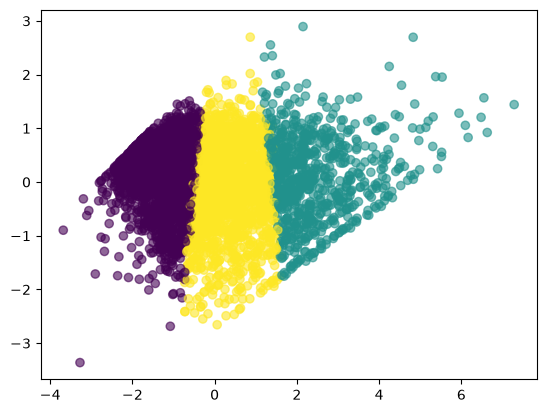

In [49]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
print(pca.fit_transform(X_scaled))

scatter = plt.scatter(
    pca.fit_transform(X_scaled)[:, 0],
    pca.fit_transform(X_scaled)[:, 1],
    c=rfm["Cluster"],
    alpha=0.6
)
plt.show()


In [ ]:
from sklearn.ensemble import RandomForestClassifier 
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

x = rfm[["Recence", "Frequence", "Montant"]] 
y = rfm["Cluster"]

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

model_jdid = RandomForestClassifier(n_estimators=100, random_state=42)
model_jdid.fit(x_train, y_train)
model_predict = model_jdid.predict(x_test)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train_scaled, y_train)       
y_pred = knn.predict(x_test_scaled)    

accuracy = accuracy_score(y_test, model_predict)
precision = precision_score(y_test, model_predict, average="weighted")
recall = recall_score(y_test, model_predict, average="weighted")
f1 = f1_score(y_test, model_predict, average="weighted")
cm = confusion_matrix(y_test, model_predict)

print(accuracy)
print(precision)
print(recall)
print(f1)

print("knn", accuracy_score(y_test, y_pred))

print("RainForestClassifier" ,accuracy)

0.9850230414746544
0.9850661705776278
0.9850230414746544
0.9850292868920715
knn 0.967741935483871
rainforestClassifier 0.9850230414746544


In [ ]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.datasets import load_iris
from sklearn.svm import SVC

data = load_iris()
X, y = data.data, data.target

model = RandomForestClassifier()
kf = KFold(n_splits=5, shuffle=True, random_state=42)

model_score = cross_val_score(model, X, y, cv=kf)

print(model_score)

[1.         0.96666667 0.93333333 0.93333333 0.96666667]
0.9600000000000002
